# Movie Rating Prediction — Final Evaluation

**Notebook:** `05_final_evaluation.ipynb`
**Depends on:** `src/data_preprocessing.py` (Phase 2), the split of Phase 3, the model selected in Phase 4

## 1. Phase 5 Overview

This is the **final, one-time evaluation** of the model chosen in Phase 4, on the test set that has been reserved
since Phase 3 and used nowhere else.

```
raw CSV (read-only)
   ↓  build_modeling_frame                     7,919 rated rows
   ↓  group-aware split (Name+Year, 80/20, random_state=42)   ← identical to Phase 3
training rows (6,335)                    test rows (1,584)  ← untouched until Section 11
   ↓ fit preprocessor + model                      ↓ transform with the fitted preprocessor
   └───────────────────────────────────────────────┴→ predict once → final metrics
```

**Final model (fixed by Phase 4, not changed here):** `GradientBoostingRegressor(n_estimators=600,
learning_rate=0.05, max_depth=4, min_samples_leaf=10, subsample=0.8, random_state=42)`, the full primary feature set
and the Phase 2 thresholds (director ≥ 10, actor ≥ 20).

**Rules followed in this notebook**

- The test set is used **once**, for the final metrics. No tuning, feature change or threshold change happens after
  that point.
- Everything learned from data (imputation values, genre vocabulary, director and actor counts) is fitted on the
  **training rows only**.
- `Votes` is not a feature, and `Rating` is only the target.
- No model file is saved; persistence belongs to Phase 6.

The three evaluation methods in this project answer **different questions** and are never mixed:

| Phase | Method | Question |
|---|---|---|
| 3 | one 80/20 holdout | how did first-pass models compare on one unseen split? |
| 4 | 5-fold group CV on the training rows | which model and configuration generalises best, with variability? |
| 5 | the same holdout test set, one evaluation | how does the finally selected model perform on unseen data? |

## 2. Imports and Configuration

In [1]:
import hashlib
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (explained_variance_score, mean_absolute_error, median_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.model_selection import GroupShuffleSplit

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "dataset" / "IMDb Movies India.csv"
FIG_DIR = PROJECT_ROOT / "visualizations"
NOTEBOOKS = PROJECT_ROOT / "notebooks"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import data_preprocessing as dp

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Fixed by Phase 4 — not tuned in this notebook
FINAL_PARAMS = dict(n_estimators=600, learning_rate=0.05, max_depth=4, min_samples_leaf=10,
                    subsample=0.8, random_state=RANDOM_STATE)
DIRECTOR_MIN_COUNT, ACTOR_MIN_COUNT = 10, 20

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)

PRIMARY, ACCENT, NEUTRAL, MUTED = "#2a78d6", "#eb6834", "#a3a29c", "#52514e"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": "#c9c8c2", "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e5e0", "xtick.color": MUTED, "ytick.color": MUTED,
})

DIAG = {}

## 3. Load Dataset

In [2]:
raw = dp.load_raw_data(DATA_PATH)   # encoding="latin-1" inside the loader
print(f"Raw data: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
raw.head(3)

Raw data: 15,509 rows × 10 columns


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana


## 4. Verify Raw Dataset Integrity

In [3]:
PHASE1_SHA256 = "68295a15943a675f38fe8c49af8f5d51b4b833aadb8a4da79da74b0a61c36479"
file_sha256 = lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()
start_hash = file_sha256(DATA_PATH)
print(f"SHA-256        : {start_hash}")
print(f"Matches Phase 1: {start_hash == PHASE1_SHA256}")
assert start_hash == PHASE1_SHA256

SHA-256        : 68295a15943a675f38fe8c49af8f5d51b4b833aadb8a4da79da74b0a61c36479
Matches Phase 1: True


## 5. Prepare Modeling Data

Row-wise cleaning only: parsing, exact-duplicate removal and keeping rated rows. Missing ratings are never imputed.

In [4]:
model_df, row_log = dp.build_modeling_frame(raw)
X, y = dp.get_features_and_target(model_df)
groups = dp.make_group_id(model_df)

print(pd.Series(row_log).to_string())
print(f"\nFeature inputs: {list(X.columns)}")
print(f"Target        : {y.name} (missing: {y.isna().sum()})")

FORBIDDEN = {"Rating", "Votes", "Votes_eda"}
DIAG["01 No target leakage: Rating absent from feature inputs"] = dp.TARGET not in X.columns
DIAG["02 Votes absent from the primary feature inputs"] = not FORBIDDEN & set(X.columns)

raw_rows                        15509
exact_duplicates_removed            6
exact_duplicates_with_rating        0
rows_after_dedup                15503
unrated_rows_excluded            7584
modeling_rows                    7919

Feature inputs: ['Year', 'Duration_min', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
Target        : Rating (missing: 0)


## 6. Recreate the Phase 3 Split

Same function, same parameters, same group key as Phase 3: `GroupShuffleSplit(n_splits=1, test_size=0.2,
random_state=42)` over the normalised `Name + Year` groups from `dp.make_group_id`.

In [5]:
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

pd.Series({
    "Total modeling rows": len(X),
    "Training rows": len(X_train),
    "Test rows": len(X_test),
    "Training share of rows": f"{len(X_train) / len(X):.1%}",
    "Training groups": g_train.nunique(),
    "Test groups": g_test.nunique(),
}, name="value").to_frame()

,value
Total modeling rows,7919
Training rows,6335
Test rows,1584
Training share of rows,80.0%
Training groups,6332
Test groups,1584


## 7. Verify the Split Matches Phase 3 Exactly

Phase 3 reported 6,335 training rows in 6,332 groups and 1,584 test rows in 1,584 groups. If these numbers did not
match, the notebook would stop here rather than continue with a different split.

In [6]:
PHASE3_SPLIT = {"train_rows": 6335, "test_rows": 1584, "train_groups": 6332, "test_groups": 1584}
actual_split = {"train_rows": len(X_train), "test_rows": len(X_test),
                "train_groups": g_train.nunique(), "test_groups": g_test.nunique()}
split_check = pd.DataFrame({"Phase 3": PHASE3_SPLIT, "Phase 5": actual_split})
split_check["matches"] = split_check["Phase 3"] == split_check["Phase 5"]

overlap = set(g_train) & set(g_test)
print(f"set(train_groups) ∩ set(test_groups) = {overlap if overlap else 'set()  (empty)'}")
print(f"Group overlap count: {len(overlap)}")

assert split_check["matches"].all(), "Recreated split does NOT match Phase 3 — stop and investigate"
assert len(overlap) == 0
assert set(train_idx).isdisjoint(test_idx) and len(train_idx) + len(test_idx) == len(X)

DIAG["03 Phase 3 split reproduced exactly (rows and groups)"] = bool(split_check["matches"].all())
DIAG["04 Training/test group overlap is zero"] = len(overlap) == 0
split_check

set(train_groups) ∩ set(test_groups) = set()  (empty)
Group overlap count: 0


,Phase 3,Phase 5,matches
train_rows,6335,6335,True
test_rows,1584,1584,True
train_groups,6332,6332,True
test_groups,1584,1584,True


In [7]:
print("Target distribution in each split:")
pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).T.round(3)

Target distribution in each split:


,count,mean,std,min,25%,50%,75%,max
train,6335.0,5.834,1.379,1.1,4.9,6.0,6.8,10.0
test,1584.0,5.873,1.391,1.6,4.9,6.0,6.9,9.7


## 8. Fit the Final Preprocessor (Training Rows Only)

The transformer is fitted on the **complete training portion** and never sees the test rows or the target.

In [8]:
preprocessor = dp.build_feature_transformer(director_min_count=DIRECTOR_MIN_COUNT,
                                            actor_min_count=ACTOR_MIN_COUNT)
preprocessor.fit(X_train)   # training rows only, no y passed

numeric_step = preprocessor.named_transformers_["numeric"]
director_step = preprocessor.named_transformers_["director"]
actor_step = preprocessor.named_transformers_["actors"]
genre_step = preprocessor.named_transformers_["genre"]

print(f"Duration median (train)     : {numeric_step.duration_median_}")
print(f"Duration decade medians     : {numeric_step.duration_decade_medians_}")
print(f"Genre vocabulary            : {len(genre_step.vocabulary_)} genres")
print(f"Directors counted / one-hot : {len(director_step.name_counts_):,} / {len(director_step.frequent_names_)}")
print(f"Actors counted / multi-hot  : {len(actor_step.name_counts_):,} / {len(actor_step.frequent_names_)}")

Duration median (train)     : 135.0
Duration decade medians     : {1930.0: 142.5, 1940.0: 137.5, 1950.0: 142.5, 1960.0: 146.0, 1970.0: 137.0, 1980.0: 140.0, 1990.0: 148.0, 2000.0: 135.0, 2010.0: 120.0, 2020.0: 111.0}
Genre vocabulary            : 22 genres
Directors counted / one-hot : 2,691 / 113
Actors counted / multi-hot  : 5,271 / 173


In [9]:
# The learned statistics must come from the training rows alone
manual_director_counts = X_train["Director"].dropna().value_counts().to_dict()
test_only_directors = set(X_test["Director"].dropna()) - set(X_train["Director"].dropna())
leaked = test_only_directors & set(director_step.name_counts_)
manual_duration_median = float(pd.to_numeric(X_train["Duration_min"], errors="coerce").median())

print("Fitted director counts equal counts from X_train only :", director_step.name_counts_ == manual_director_counts)
print(f"Directors only in the test set                        : {len(test_only_directors):,}; of those in fitted stats: {len(leaked)}")
print("Fitted Duration median equals the X_train median      :", numeric_step.duration_median_ == manual_duration_median)

DIAG["05 Preprocessing fitted on training rows only (director counts, duration median)"] = (
    director_step.name_counts_ == manual_director_counts and numeric_step.duration_median_ == manual_duration_median)
DIAG["06 No test-only name leaked into the fitted preprocessing statistics"] = not leaked

Fitted director counts equal counts from X_train only : True
Directors only in the test set                        : 448; of those in fitted stats: 0
Fitted Duration median equals the X_train median      : True


## 9. Transform Train and Test

In [10]:
Xt_train = preprocessor.transform(X_train)
Xt_test = preprocessor.transform(X_test)   # transform only; the test rows are never fitted on
feature_names = list(Xt_train.columns)

print(f"Transformed training matrix: {Xt_train.shape}")
print(f"Transformed test matrix    : {Xt_test.shape}")

train_arr, test_arr = Xt_train.to_numpy(dtype=float), Xt_test.to_numpy(dtype=float)
DIAG["07 No NaN values in the transformed matrices"] = not (np.isnan(train_arr).any() or np.isnan(test_arr).any())
DIAG["08 No infinite values in the transformed matrices"] = bool(np.isfinite(train_arr).all() and np.isfinite(test_arr).all())
DIAG["09 Train and test feature columns identical and in the same order"] = feature_names == list(Xt_test.columns)

pd.Series({name: len(step.get_feature_names_out()) for name, step, _ in preprocessor.transformers_
           if name != "remainder"} | {"total": len(feature_names)}, name="columns").to_frame()

Transformed training matrix: (6335, 322)
Transformed test matrix    : (1584, 322)


,columns
numeric,3
genre,24
director,115
actors,180
total,322


## 10. Train the Final Model

The model is trained **once**, on the complete transformed training matrix, with the parameters fixed in Phase 4.

In [11]:
FIT_CALLS = []

final_model = GradientBoostingRegressor(**FINAL_PARAMS)
final_model.fit(Xt_train, y_train)
FIT_CALLS.append("final_model.fit(Xt_train, y_train)")

params_after_training = {k: final_model.get_params()[k] for k in FINAL_PARAMS}
print("Final model parameters:", params_after_training)
DIAG["10 Model parameters match the Phase 4 candidate exactly"] = params_after_training == FINAL_PARAMS
DIAG["11 Final model trained exactly once, on the full training data"] = (
    len(FIT_CALLS) == 1 and final_model.n_features_in_ == Xt_train.shape[1])
print(f"Training rows used: {Xt_train.shape[0]:,}; features: {final_model.n_features_in_}")

Final model parameters: {'n_estimators': 600, 'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 10, 'subsample': 0.8, 'random_state': 42}
Training rows used: 6,335; features: 322


## 11. Final Test Evaluation

This is the **single** evaluation on the reserved test set.

In [12]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MAE": mean_absolute_error(y_true, y_pred), "MSE": mse, "RMSE": float(np.sqrt(mse)),
            "R²": r2_score(y_true, y_pred)}

y_pred = final_model.predict(Xt_test)
final_metrics = regression_metrics(y_test, y_pred)

DIAG["12 Prediction count equals the test row count"] = len(y_pred) == len(y_test)
DIAG["13 Predictions contain no NaN or infinite values"] = bool(np.isfinite(y_pred).all())

extra = {
    "Median absolute error": median_absolute_error(y_test, y_pred),
    "Maximum absolute error": float(np.abs(y_test - y_pred).max()),
    "Explained variance": explained_variance_score(y_test, y_pred),
}
print("FINAL TEST METRICS (primary)")
for k in ["MAE", "MSE", "RMSE", "R²"]:
    print(f"  {k:<5}: {final_metrics[k]:.4f}")
print("\nSecondary metrics")
for k, v in extra.items():
    print(f"  {k:<22}: {v:.4f}")

FINAL TEST METRICS (primary)
  MAE  : 0.8862
  MSE  : 1.3453
  RMSE : 1.1599
  R²   : 0.3046

Secondary metrics
  Median absolute error : 0.6966
  Maximum absolute error: 5.1441
  Explained variance    : 0.3046


The primary metrics stay MAE, RMSE and R². The secondary ones only add detail: the median absolute error shows the
typical error away from the extremes, and the maximum shows the worst single case.

## 12. Final Baseline

The baseline predicts the **mean rating of the training set** for every test film.

In [13]:
baseline = DummyRegressor(strategy="mean").fit(Xt_train, y_train)
y_pred_baseline = baseline.predict(Xt_test)
baseline_metrics = regression_metrics(y_test, y_pred_baseline)

print(f"Training mean rating used: {baseline.constant_[0][0]:.4f}")
print(f"(Test mean, not used for fitting: {y_test.mean():.4f})")
assert np.isclose(baseline.constant_[0][0], y_train.mean())
DIAG["14 Baseline uses the training mean, not the global or test mean"] = bool(np.isclose(baseline.constant_[0][0], y_train.mean()))

final_vs_baseline = pd.DataFrame({"Baseline (train mean)": baseline_metrics,
                                  "Final tuned Gradient Boosting": final_metrics}).T
final_vs_baseline["MAE improvement"] = 1 - final_vs_baseline["MAE"] / baseline_metrics["MAE"]
final_vs_baseline["RMSE improvement"] = 1 - final_vs_baseline["RMSE"] / baseline_metrics["RMSE"]
DIAG["15 All final metrics are finite"] = bool(np.isfinite(final_vs_baseline[["MAE", "MSE", "RMSE", "R²"]].to_numpy()).all())
final_vs_baseline.round(4)

Training mean rating used: 5.8339
(Test mean, not used for fitting: 5.8727)


,MAE,MSE,RMSE,R²,MAE improvement,RMSE improvement
Baseline (train mean),1.1243,1.9361,1.3914,-0.0008,0.0000,0.0000
Final tuned Gradient Boosting,0.8862,1.3453,1.1599,0.3046,0.2117,0.1664


## 13. Phase 3 vs Phase 4 vs Phase 5

The Phase 3 and Phase 4 figures are **read from the saved outputs** of their notebooks, not recomputed. The
methodologies differ, so the columns are labelled separately and must not be read as the same measurement.

In [14]:
import nbformat

def notebook_output_text(path):
    nb = nbformat.read(path, as_version=4)
    return "\n".join(o.get("text", "") for c in nb.cells if c.cell_type == "code" for o in c.outputs)

phase3_text = notebook_output_text(NOTEBOOKS / "03_model_training.ipynb")
phase3 = {}
for name in ["Gradient Boosting", "Random Forest", "Linear Regression", "Baseline (train mean)"]:
    m = re.search(re.escape(name) + r"\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)", phase3_text)
    if m:
        phase3[name] = dict(zip(["MAE", "MSE", "RMSE", "R²"], map(float, m.groups())))

phase4_text = notebook_output_text(NOTEBOOKS / "04_model_improvement.ipynb")
phase4 = {}
for m in re.finditer(r"^\s{2}(.+?)\s{2,}RMSE ([\d.]+) ± ([\d.]+) \| MAE ([\d.]+) ± ([\d.]+).*?R² ([-\d.]+)",
                     phase4_text, re.MULTILINE):
    phase4[m.group(1).strip()] = {"RMSE": float(m.group(2)), "RMSE std": float(m.group(3)),
                                  "MAE": float(m.group(4)), "R²": float(m.group(6))}
print(f"Parsed {len(phase3)} Phase 3 models and {len(phase4)} Phase 4 models from saved notebook outputs")
DIAG["16 Phase 3 / Phase 4 reference values read from saved notebook outputs"] = len(phase3) == 4 and len(phase4) >= 4

Parsed 4 Phase 3 models and 6 Phase 4 models from saved notebook outputs


In [15]:
rows = []
for name, m in phase3.items():
    label = "Baseline (train mean)" if name.startswith("Baseline") else name
    rows.append({"Model": label, "Evaluation": "Phase 3 — single holdout test",
                 "MAE": m["MAE"], "RMSE": m["RMSE"], "R²": m["R²"], "RMSE std": np.nan})
for name, m in phase4.items():
    rows.append({"Model": name.replace("(fold-train mean)", "(train mean)"),
                 "Evaluation": "Phase 4 — 5-fold group CV (training rows)",
                 "MAE": m["MAE"], "RMSE": m["RMSE"], "R²": m["R²"], "RMSE std": m["RMSE std"]})
rows.append({"Model": "Baseline (train mean)", "Evaluation": "Phase 5 — FINAL holdout test",
             **{k: baseline_metrics[k] for k in ["MAE", "RMSE", "R²"]}, "RMSE std": np.nan})
rows.append({"Model": "Gradient Boosting (tuned)", "Evaluation": "Phase 5 — FINAL holdout test",
             **{k: final_metrics[k] for k in ["MAE", "RMSE", "R²"]}, "RMSE std": np.nan})

comparison = pd.DataFrame(rows).set_index(["Evaluation", "Model"]).sort_index()
comparison.round(4)

MAE    RMSE      R²  RMSE std
Evaluation                                Model                                                      
Phase 3 — single holdout test             Baseline (train mean)      1.1243  1.3914 -0.0008       NaN
                                          Gradient Boosting          0.9044  1.1791  0.2813       NaN
                                          Linear Regression          0.9424  1.2197  0.2311       NaN
                                          Random Forest              0.9101  1.1832  0.2764       NaN
Phase 4 — 5-fold group CV (training rows) Baseline (train mean)      1.1242  1.3794 -0.0016    0.0318
                                          Gradient Boosting          0.9213  1.1761  0.2720    0.0318
                                          Gradient Boosting (tuned)  0.9009  1.1549  0.2980    0.0363
                                          Linear Regression          0.9624  1.2232  0.2123    0.0237
                                          Random Forest              0.9167  1.1733  0.2755    0.0344
                                          Random Forest (tuned)      0.9167  1.1733  0.2755    0.0344
Phase 5 — FINAL holdout test              Baseline (train mean)      1.1243  1.3914 -0.0008       NaN
                                          Gradient Boosting (tuned)  0.8862  1.1599  0.3046       NaN

In [16]:
p3_gb = phase3["Gradient Boosting"]
print("Final tuned Gradient Boosting (Phase 5 test) vs Phase 3 Gradient Boosting (same test set):")
for k in ["MAE", "RMSE", "R²"]:
    diff = final_metrics[k] - p3_gb[k]
    direction = "better" if (diff < 0 if k != "R²" else diff > 0) else "worse"
    print(f"  {k:<5}: {p3_gb[k]:.4f} → {final_metrics[k]:.4f}  ({diff:+.4f}, {direction})")
print(f"\nPhase 4 CV estimate for this model: RMSE {phase4['Gradient Boosting (tuned)']['RMSE']:.4f} "
      f"± {phase4['Gradient Boosting (tuned)']['RMSE std']:.4f} (training rows, 5 folds)")
print(f"Phase 5 final test RMSE           : {final_metrics['RMSE']:.4f} (1,584 unseen films, single evaluation)")

Final tuned Gradient Boosting (Phase 5 test) vs Phase 3 Gradient Boosting (same test set):
  MAE  : 0.9044 → 0.8862  (-0.0182, better)
  RMSE : 1.1791 → 1.1599  (-0.0192, better)
  R²   : 0.2813 → 0.3046  (+0.0233, better)

Phase 4 CV estimate for this model: RMSE 1.1549 ± 0.0363 (training rows, 5 folds)
Phase 5 final test RMSE           : 1.1599 (1,584 unseen films, single evaluation)


Both Phase 3 models and the Phase 5 model were scored on the **same** test films, so that comparison is direct. The
Phase 4 CV number is an average over different validation splits of the training rows and is shown for context only.

## 14. Detailed Error Analysis

In [17]:
test_rows = model_df.loc[X_test.index]
residuals = y_test - y_pred

errors = pd.DataFrame({
    "Name": test_rows["Name"],
    "Year": test_rows["Year"].astype("Int64"),
    "Actual Rating": y_test,
    "Predicted Rating": y_pred,
    "Residual": residuals,
    "Absolute Error": residuals.abs(),
    "Genre": test_rows["Genre"],
    "Director": test_rows["Director"],
    "Actor 1": test_rows["Actor 1"],
    "Actor 2": test_rows["Actor 2"],
    "Actor 3": test_rows["Actor 3"],
    "Duration_min": test_rows["Duration_min"],
    "director_train_films": Xt_test["director_count"],
    "actors_listed": Xt_test["actor_listed"],
    "duration_missing": Xt_test["duration_missing"].astype(bool),
    "Votes (diagnostic only)": test_rows["Votes_eda"],
}).sort_values("Absolute Error", ascending=False)

print(f"Test films: {len(errors):,}")
print(errors["Absolute Error"].describe().round(3).to_string())
errors.head(10).round(2)

Test films: 1,584
count    1584.000
mean        0.886
std         0.748
min         0.002
25%         0.313
50%         0.697
75%         1.266
max         5.144


,Name,Year,Actual Rating,Predicted Rating,Residual,Absolute Error,Genre,Director,Actor 1,Actor 2,Actor 3,Duration_min,director_train_films,actors_listed,duration_missing,Votes (diagnostic only)
6462,Searching for Sheela,2021,4.1,9.24,-5.14,5.14,"Documentary, Biography, Crime",Shakun Batra,Ma Anand Sheela,Shoma Chaudhury,Anurag Chauhan,58.0,2,3,False,553.0
4995,Mumbai Can Dance Saalaa,2015,1.6,5.89,-4.29,4.29,Drama,Sachindra Sharma,Shakti Kapoor,Prashant Narayanan,Aditya Pancholi,135.0,1,3,False,43.0
4209,Lahore Confidential,2021,2.8,7.07,-4.27,4.27,"Crime, Drama, Thriller",Kunal Kohli,Richa Chadha,Nikhat Khan,Abdullah Osman,68.0,5,3,False,522.0
7146,The Dirty MMS,2014,2.4,6.53,-4.13,4.13,Drama,Sudhir Pillai,Rakesh,Sudhir,Gunj,93.0,0,3,False,18.0
4568,Man on Mission Taqatwar,2005,8.7,4.70,4.00,4.00,Action,Abbas,Aishwarya,Mohan Babu,Charmy Kaur,<NA>,0,3,True,84.0
2310,Ek Haseena Thi Ek Deewana Tha,2017,2.5,6.44,-3.94,3.94,Drama,Suneel Darshan,Shiv Darshan,Natasha Fernandez,Upen Patel,105.0,7,3,False,104.0
6848,Student of the Year 2,2019,2.2,6.12,-3.92,3.92,"Action, Comedy, Drama",Punit Malhotra,Tiger Shroff,Ananya Panday,Tara Sutaria,146.0,2,3,False,17483.0
4512,Main Hoon Khiladiyon Ka Khiladi,2004,8.8,4.91,3.89,3.89,Action,K. Muralimohana Rao,Mohan Babu,Chiranjeevi,Pran,<NA>,9,3,True,92.0
3355,Jackpot,2013,2.0,5.82,-3.82,3.82,"Comedy, Thriller",Kaizad Gustad,Naseeruddin Shah,Sunny Leone,Sachiin Joshi,132.0,1,3,False,721.0
3127,Humshakals,2014,1.8,5.54,-3.74,3.74,"Comedy, Drama, Romance",Sajid Khan,Saif Ali Khan,Riteish Deshmukh,Ram Kapoor,159.0,4,3,False,7840.0


## 15. Extreme Rating Analysis

Groups: **Low** (rating < 4), **Medium** (4 to < 7), **High** (≥ 7).

In [18]:
group_bins = pd.cut(errors["Actual Rating"], bins=[-np.inf, 4, 7, np.inf], right=False,
                    labels=["Low (<4)", "Medium (4–7)", "High (≥7)"])
rating_groups = errors.assign(sq_error=errors["Residual"] ** 2).groupby(group_bins, observed=True).agg(
    films=("Absolute Error", "size"),
    MAE=("Absolute Error", "mean"),
    mean_sq=("sq_error", "mean"),
    **{"mean actual": ("Actual Rating", "mean"), "mean predicted": ("Predicted Rating", "mean"),
       "mean residual": ("Residual", "mean")})
rating_groups.insert(2, "RMSE", np.sqrt(rating_groups.pop("mean_sq")))
rating_groups.index.name = "rating group"
rating_groups.round(3)

,films,MAE,RMSE,mean actual,mean predicted,mean residual
rating group,,,,,,
Low (<4),152,2.039,2.195,3.191,5.230,-2.039
Medium (4–7),1076,0.642,0.833,5.682,5.751,-0.069
High (≥7),356,1.133,1.354,7.593,6.485,1.108


In [19]:
def spread(s):
    return {"min": s.min(), "p5": s.quantile(0.05), "median": s.median(), "mean": s.mean(),
            "p95": s.quantile(0.95), "max": s.max(), "std": s.std()}

spread_table = pd.DataFrame({"Actual rating": spread(errors["Actual Rating"]),
                             "Predicted rating": spread(errors["Predicted Rating"])}).T
spread_table["p95 − p5 span"] = spread_table["p95"] - spread_table["p5"]
spread_table.round(3)

,min,p5,median,mean,p95,max,std,p95 − p5 span
Actual rating,1.600,3.315,6.000,5.873,7.900,9.700,1.391,4.585
Predicted rating,3.457,4.546,5.874,5.866,7.188,9.244,0.819,2.643


## 16. Residual Analysis

`residual = actual − predicted`. A positive residual means the model predicted **too low** for that film.

In [20]:
print(f"Mean residual    : {residuals.mean():+.4f}")
print(f"Median residual  : {residuals.median():+.4f}")
print(f"Std of residuals : {residuals.std():.4f}")
print(f"Share positive   : {(residuals > 0).mean():.1%}")
print(f"Within ±0.5      : {(residuals.abs() <= 0.5).mean():.1%}")
print(f"Within ±1.0      : {(residuals.abs() <= 1.0).mean():.1%}")
print(f"Beyond ±2.0      : {(residuals.abs() > 2.0).mean():.1%}")
rating_groups[["films", "mean residual", "MAE"]].round(3)

Mean residual    : +0.0067
Median residual  : +0.0859
Std of residuals : 1.1602
Share positive   : 54.3%
Within ±0.5      : 38.0%
Within ±1.0      : 64.6%
Beyond ±2.0      : 8.8%


,films,mean residual,MAE
rating group,,,
Low (<4),152,-2.039,2.039
Medium (4–7),1076,-0.069,0.642
High (≥7),356,1.108,1.133


## 17. Error by Data Characteristics

Bins with very few films are shown but should not be over-interpreted; the `films` column gives the sample size.

In [21]:
director_band = pd.cut(errors["director_train_films"], bins=[-1, 0, 4, 9, np.inf],
                       labels=["unseen in training", "1–4 films", "5–9 films", "10+ films"])
duration_band = pd.cut(errors["Duration_min"].astype(float), bins=[0, 60, 90, 120, 150, np.inf],
                       labels=["<60 min", "60–90", "90–120", "120–150", ">150"])
decade = (errors["Year"] // 10 * 10).astype("Int64")

def error_by(group, name):
    out = errors.groupby(group, observed=True).agg(films=("Absolute Error", "size"), MAE=("Absolute Error", "mean"),
                                                   mean_residual=("Residual", "mean"))
    out.index.name = name
    return out.round(3)

print("By director history in the training data:")
display(error_by(director_band, "director history"))
print("By duration band (films with a known duration):")
display(error_by(duration_band, "duration"))

By director history in the training data:


,films,MAE,mean_residual
director history,,,
unseen in training,476,0.984,-0.045
1–4 films,466,0.956,0.008
5–9 films,294,0.828,0.002
10+ films,348,0.708,0.079


By duration band (films with a known duration):

,films,MAE,mean_residual
duration,,,
<60 min,10,1.674,-1.624
60–90,72,0.937,-0.176
90–120,296,0.974,0.064
120–150,555,0.827,-0.056
>150,262,0.866,0.073


In [22]:
print("By release decade:")
display(error_by(decade, "decade"))
print("By missing metadata:")
display(pd.concat({
    "duration missing": error_by(errors["duration_missing"], "value"),
    "genre missing": error_by(errors["Genre"].isna(), "value"),
    "fewer than 3 actors listed": error_by(errors["actors_listed"] < 3, "value"),
}))

By release decade:


,films,MAE,mean_residual
decade,,,
1930,16,0.547,0.127
1940,29,0.667,-0.117
1950,63,0.602,0.229
1960,110,0.540,-0.054
1970,174,0.652,-0.014
1980,227,0.713,0.110
1990,207,0.871,0.107
2000,292,1.051,0.003
2010,410,1.067,-0.095


By missing metadata:


films    MAE  mean_residual
                           value                             
duration missing           False   1195  0.886         -0.019
                           True     389  0.887          0.084
genre missing              False   1561  0.883          0.011
                           True      23  1.106         -0.271
fewer than 3 actors listed False   1524  0.878          0.008
                           True      60  1.098         -0.014

In [23]:
genre_long = (errors[["Genre", "Absolute Error", "Residual"]].dropna(subset=["Genre"])
              .assign(Genre=lambda d: d["Genre"].str.split(","))
              .explode("Genre").assign(Genre=lambda d: d["Genre"].str.strip()))
genre_errors = genre_long.groupby("Genre").agg(films=("Absolute Error", "size"), MAE=("Absolute Error", "mean"),
                                               mean_residual=("Residual", "mean"))
MIN_GENRE_FILMS = 30
print(f"By genre (genres with at least {MIN_GENRE_FILMS} test films; a film counts in each of its genres):")
genre_errors[genre_errors["films"] >= MIN_GENRE_FILMS].sort_values("MAE", ascending=False).round(3)

By genre (genres with at least 30 test films; a film counts in each of its genres):


,films,MAE,mean_residual
Genre,,,
Biography,36,1.039,-0.197
Horror,50,0.995,-0.020
Comedy,298,0.962,-0.062
Documentary,36,0.960,0.023
Crime,230,0.928,-0.023
Action,466,0.894,0.003
Drama,971,0.857,-0.016
Romance,340,0.835,0.093
Thriller,191,0.829,0.030


## 18. Top 20 Largest Errors

In [24]:
top20 = errors.head(20)
top20[["Name", "Year", "Actual Rating", "Predicted Rating", "Residual", "Absolute Error", "Genre",
       "Director", "Duration_min", "director_train_films", "Votes (diagnostic only)"]].round(2)

,Name,Year,Actual Rating,Predicted Rating,Residual,Absolute Error,Genre,Director,Duration_min,director_train_films,Votes (diagnostic only)
6462,Searching for Sheela,2021,4.1,9.24,-5.14,5.14,"Documentary, Biography, Crime",Shakun Batra,58.0,2,553.0
4995,Mumbai Can Dance Saalaa,2015,1.6,5.89,-4.29,4.29,Drama,Sachindra Sharma,135.0,1,43.0
4209,Lahore Confidential,2021,2.8,7.07,-4.27,4.27,"Crime, Drama, Thriller",Kunal Kohli,68.0,5,522.0
7146,The Dirty MMS,2014,2.4,6.53,-4.13,4.13,Drama,Sudhir Pillai,93.0,0,18.0
4568,Man on Mission Taqatwar,2005,8.7,4.70,4.00,4.00,Action,Abbas,<NA>,0,84.0
2310,Ek Haseena Thi Ek Deewana Tha,2017,2.5,6.44,-3.94,3.94,Drama,Suneel Darshan,105.0,7,104.0
6848,Student of the Year 2,2019,2.2,6.12,-3.92,3.92,"Action, Comedy, Drama",Punit Malhotra,146.0,2,17483.0
4512,Main Hoon Khiladiyon Ka Khiladi,2004,8.8,4.91,3.89,3.89,Action,K. Muralimohana Rao,<NA>,9,92.0
3355,Jackpot,2013,2.0,5.82,-3.82,3.82,"Comedy, Thriller",Kaizad Gustad,132.0,1,721.0
3127,Humshakals,2014,1.8,5.54,-3.74,3.74,"Comedy, Drama, Romance",Sajid Khan,159.0,4,7840.0


In [25]:
print("Profile of the 20 largest errors vs the rest of the test set:")
def profile(frame):
    return pd.Series({
        "films": len(frame),
        "mean actual rating": frame["Actual Rating"].mean(),
        "share rated < 4": frame["Actual Rating"].lt(4).mean(),
        "share rated ≥ 8": frame["Actual Rating"].ge(8).mean(),
        "share over-predicted": frame["Residual"].lt(0).mean(),
        "share director unseen in training": frame["director_train_films"].eq(0).mean(),
        "share duration missing": frame["duration_missing"].mean(),
        "share fewer than 3 actors": frame["actors_listed"].lt(3).mean(),
        "median votes (diagnostic)": frame["Votes (diagnostic only)"].median(),
    })
pd.DataFrame({"top 20 errors": profile(top20), "other test films": profile(errors.iloc[20:])}).round(3)

Profile of the 20 largest errors vs the rest of the test set:


,top 20 errors,other test films
films,20.000,1564.000
mean actual rating,3.805,5.899
share rated < 4,0.750,0.088
share rated ≥ 8,0.200,0.048
share over-predicted,0.800,0.453
share director unseen in training,0.350,0.300
share duration missing,0.200,0.246
share fewer than 3 actors,0.000,0.038
median votes (diagnostic),102.500,56.000


These are **observed patterns**, recorded as hypotheses for future work. The model is **not** changed in response to
them, because that would turn the test set into a tuning set.

## 19. Prediction Calibration

Mean predicted rating within each band of actual rating. If predictions were well calibrated across the scale, the
mean predicted value would track the mean actual value in every bin.

In [26]:
calib_bins = pd.cut(errors["Actual Rating"], bins=[-np.inf, 4, 5, 6, 7, 8, 9, np.inf], right=False,
                    labels=["<4", "4–<5", "5–<6", "6–<7", "7–<8", "8–<9", "≥9"])
calibration = errors.groupby(calib_bins, observed=True).agg(
    **{"count": ("Actual Rating", "size"), "mean actual": ("Actual Rating", "mean"),
       "mean predicted": ("Predicted Rating", "mean"), "mean residual": ("Residual", "mean"),
       "MAE": ("Absolute Error", "mean")})
calibration.index.name = "actual-rating bin"
calibration["small sample (<30)"] = calibration["count"] < 30
calibration.round(3)

,count,mean actual,mean predicted,mean residual,MAE,small sample (<30)
actual-rating bin,,,,,,
<4,152,3.191,5.230,-2.039,2.039,False
4–<5,256,4.515,5.347,-0.832,0.896,False
5–<6,349,5.497,5.580,-0.084,0.534,False
6–<7,471,6.455,6.097,0.357,0.583,False
7–<8,277,7.358,6.397,0.961,0.990,False
8–<9,69,8.293,6.714,1.579,1.589,False
≥9,10,9.270,7.327,1.943,1.943,True


## 20. Final Visualizations

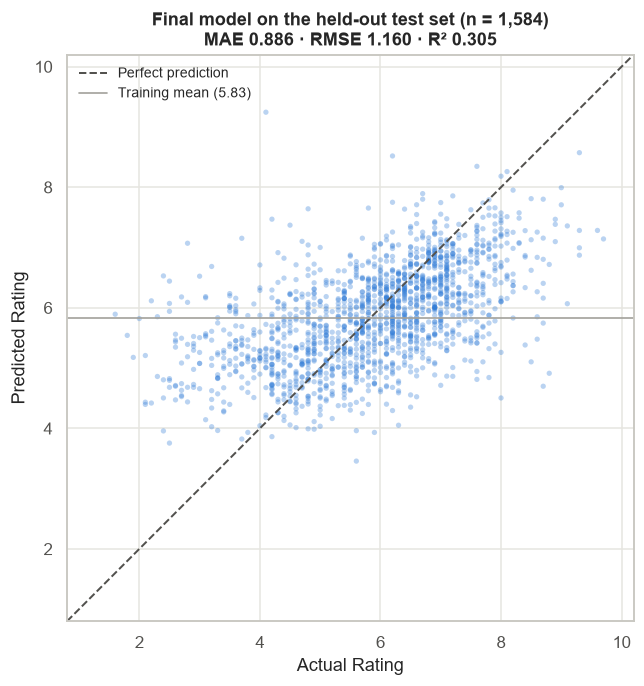

In [27]:
# 17_final_actual_vs_predicted.png
lims = (0.8, 10.2)
fig, ax = plt.subplots(figsize=(6.6, 6.4))
ax.scatter(errors["Actual Rating"], errors["Predicted Rating"], s=12, alpha=0.32, color=PRIMARY, edgecolors="none")
ax.plot(lims, lims, "--", color=MUTED, linewidth=1.3, label="Perfect prediction")
ax.axhline(y_train.mean(), color=NEUTRAL, linewidth=1.1, label=f"Training mean ({y_train.mean():.2f})")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("Actual Rating"); ax.set_ylabel("Predicted Rating")
ax.set_title(f"Final model on the held-out test set (n = {len(y_test):,})\n"
             f"MAE {final_metrics['MAE']:.3f} · RMSE {final_metrics['RMSE']:.3f} · R² {final_metrics['R²']:.3f}")
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "17_final_actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()

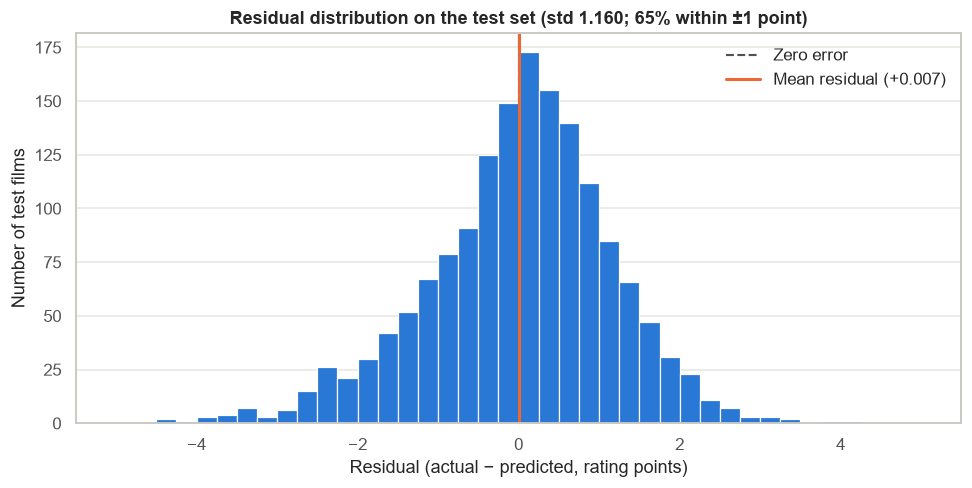

In [28]:
# 18_final_residual_distribution.png
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(residuals, bins=np.arange(-5, 5.01, 0.25), color=PRIMARY, edgecolor="white", linewidth=0.8)
ax.axvline(0, color=MUTED, linestyle="--", linewidth=1.4, label="Zero error")
ax.axvline(residuals.mean(), color=ACCENT, linewidth=2, label=f"Mean residual ({residuals.mean():+.3f})")
ax.set_xlabel("Residual (actual − predicted, rating points)")
ax.set_ylabel("Number of test films")
ax.set_title(f"Residual distribution on the test set (std {residuals.std():.3f}; "
             f"{(residuals.abs() <= 1).mean():.0%} within ±1 point)")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "18_final_residual_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

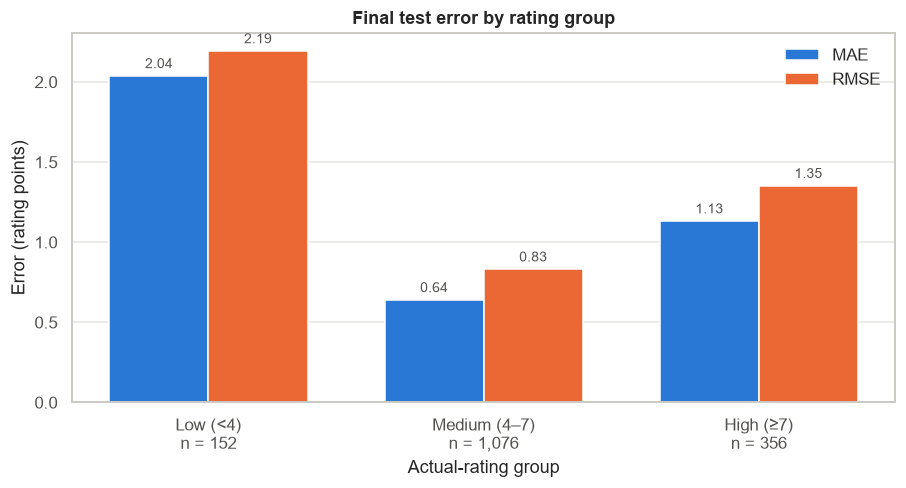

In [29]:
# 19_final_error_by_rating_group.png
labels = list(rating_groups.index)
xs = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8.4, 4.6))
for i, (metric, color) in enumerate([("MAE", PRIMARY), ("RMSE", ACCENT)]):
    bars = ax.bar(xs + (i - 0.5) * 0.36, rating_groups[metric], width=0.36, color=color, label=metric)
    ax.bar_label(bars, labels=[f"{v:.2f}" for v in rating_groups[metric]], padding=3, fontsize=9, color=MUTED)
ax.set_xticks(xs)
ax.set_xticklabels([f"{l}\nn = {int(rating_groups.loc[l, 'films']):,}" for l in labels])
ax.set_xlabel("Actual-rating group")
ax.set_ylabel("Error (rating points)")
ax.set_title("Final test error by rating group")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "19_final_error_by_rating_group.png", dpi=120, bbox_inches="tight")
plt.show()

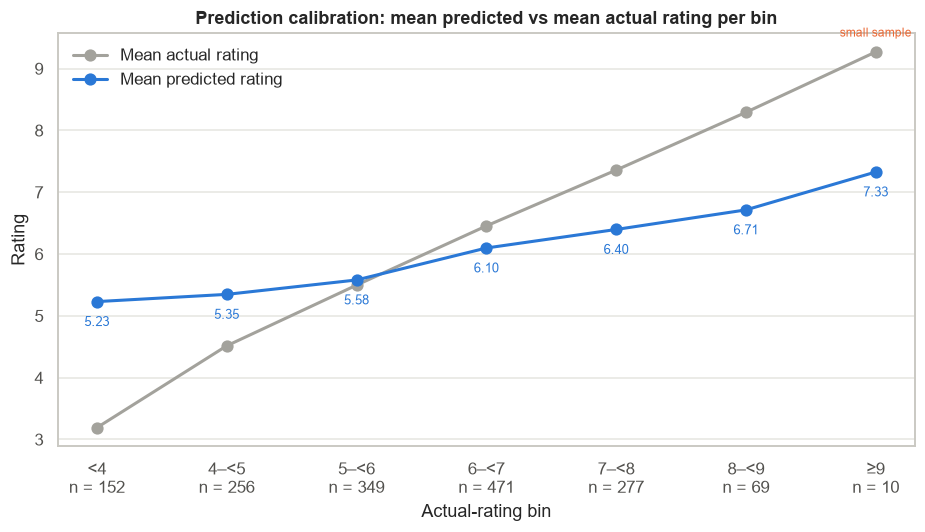

In [30]:
# 20_final_prediction_calibration.png
fig, ax = plt.subplots(figsize=(8.6, 5))
xs = np.arange(len(calibration))
ax.plot(xs, calibration["mean actual"], "-o", color=NEUTRAL, linewidth=2, markersize=7, label="Mean actual rating")
ax.plot(xs, calibration["mean predicted"], "-o", color=PRIMARY, linewidth=2, markersize=7, label="Mean predicted rating")
for i, (_, row) in enumerate(calibration.iterrows()):
    ax.annotate(f"{row['mean predicted']:.2f}", (i, row["mean predicted"]), xytext=(0, -16),
                textcoords="offset points", ha="center", fontsize=8.5, color=PRIMARY)
    if row["count"] < 30:
        ax.annotate("small sample", (i, row["mean actual"]), xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=8, color=ACCENT)
ax.set_xticks(xs)
ax.set_xticklabels([f"{b}\nn = {int(c):,}" for b, c in zip(calibration.index, calibration["count"])])
ax.set_xlabel("Actual-rating bin")
ax.set_ylabel("Rating")
ax.set_title("Prediction calibration: mean predicted vs mean actual rating per bin")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "20_final_prediction_calibration.png", dpi=120, bbox_inches="tight")
plt.show()

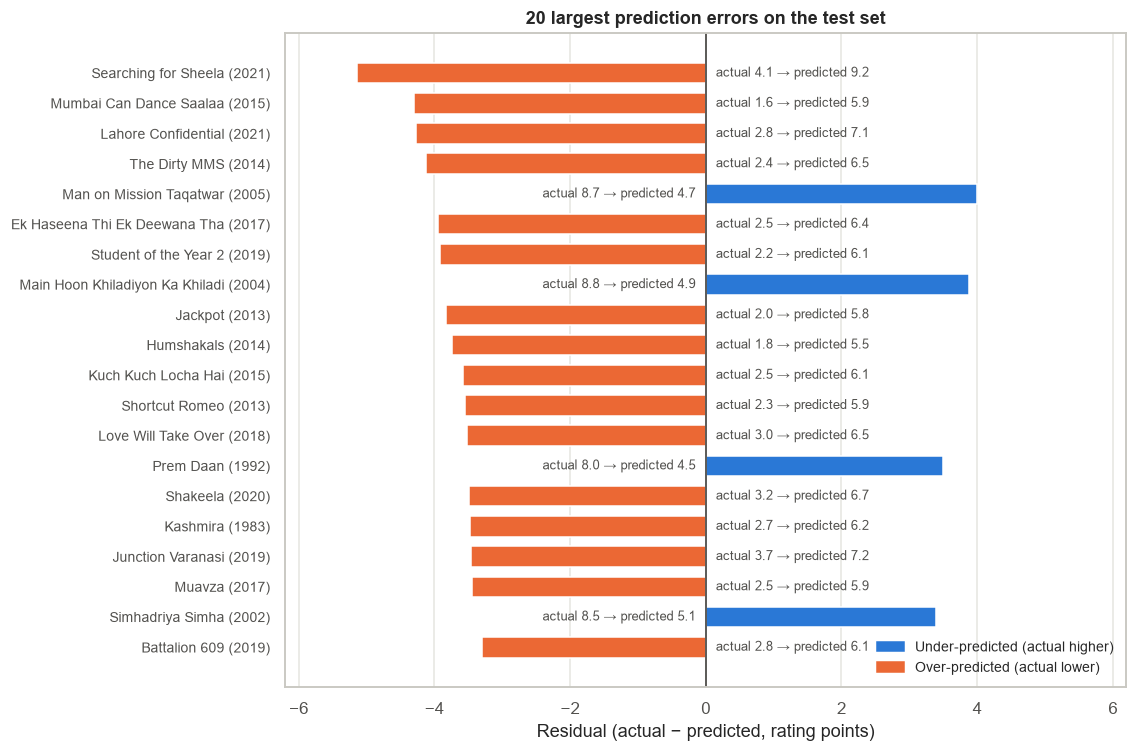

In [31]:
# 21_final_top_errors.png
top = top20.iloc[::-1]
labels = [f"{n[:34]}{'…' if len(n) > 34 else ''} ({int(yr)})" for n, yr in zip(top["Name"], top["Year"])]
colors = [ACCENT if r < 0 else PRIMARY for r in top["Residual"]]
fig, ax = plt.subplots(figsize=(10.5, 7))
bars = ax.barh(labels, top["Residual"], color=colors, height=0.68)
for bar, (_, row) in zip(bars, top.iterrows()):
    resid = row["Residual"]
    # label on the opposite side of zero from the bar, where there is always free space
    ax.text(0.15 if resid < 0 else -0.15, bar.get_y() + bar.get_height() / 2,
            f"actual {row['Actual Rating']:.1f} → predicted {row['Predicted Rating']:.1f}", va="center",
            ha="left" if resid < 0 else "right", fontsize=8.5, color=MUTED)
ax.axvline(0, color=MUTED, linewidth=1.2)
ax.set_xlim(-6.2, 6.2)
ax.set_xlabel("Residual (actual − predicted, rating points)")
ax.set_title("20 largest prediction errors on the test set")
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=PRIMARY), plt.Rectangle((0, 0), 1, 1, color=ACCENT)]
ax.legend(handles, ["Under-predicted (actual higher)", "Over-predicted (actual lower)"], frameon=False,
          loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "21_final_top_errors.png", dpi=120, bbox_inches="tight")
plt.show()

## 21. Diagnostics

In [32]:
# The model must be unchanged since it was trained: same object, same parameters, same predictions
DIAG["17 Model parameters unchanged after test evaluation (no tuning afterwards)"] = (
    {k: final_model.get_params()[k] for k in FINAL_PARAMS} == FINAL_PARAMS == params_after_training)
DIAG["18 Predictions reproducible from the same fitted model"] = np.array_equal(final_model.predict(Xt_test), y_pred)
DIAG["19 Test rows absent from the training matrix"] = not set(X_test.index) & set(X_train.index)
DIAG["20 Only one model fit performed in this notebook"] = len(FIT_CALLS) == 1
DIAG["21 Raw CSV unchanged (SHA-256 matches Phase 1)"] = file_sha256(DATA_PATH) == PHASE1_SHA256
DIAG["22 No model file written by this notebook"] = not any(
    p.suffix in {".pkl", ".joblib", ".pickle"} for p in (PROJECT_ROOT / "models").glob("*"))

diag = pd.Series(DIAG, name="passed").sort_index().to_frame()
assert diag["passed"].all(), diag[~diag["passed"]]
print(f"{int(diag['passed'].sum())} / {len(diag)} diagnostics passed")
diag

22 / 22 diagnostics passed


,passed
01 No target leakage: Rating absent from feature inputs,True
02 Votes absent from the primary feature inputs,True
03 Phase 3 split reproduced exactly (rows and groups),True
04 Training/test group overlap is zero,True
"05 Preprocessing fitted on training rows only (director counts, duration median)",True
06 No test-only name leaked into the fitted preprocessing statistics,True
07 No NaN values in the transformed matrices,True
08 No infinite values in the transformed matrices,True
09 Train and test feature columns identical and in the same order,True
10 Model parameters match the Phase 4 candidate exactly,True


## 22. Final Interpretation

In [33]:
imp_mae = 1 - final_metrics["MAE"] / baseline_metrics["MAE"]
imp_rmse = 1 - final_metrics["RMSE"] / baseline_metrics["RMSE"]
pred_std, actual_std = errors["Predicted Rating"].std(), errors["Actual Rating"].std()

print("FINAL HOLDOUT RESULTS — tuned Gradient Boosting, 1,584 unseen films")
print(f"  MAE  {final_metrics['MAE']:.4f}   RMSE {final_metrics['RMSE']:.4f}   "
      f"MSE {final_metrics['MSE']:.4f}   R² {final_metrics['R²']:.4f}")
print(f"  Median absolute error {extra['Median absolute error']:.4f} | "
      f"Maximum absolute error {extra['Maximum absolute error']:.4f}")
print(f"\nImprovement over the training-mean baseline: MAE {imp_mae:.1%}, RMSE {imp_rmse:.1%}")
print(f"Phase 3 Gradient Boosting on the same test set: MAE {p3_gb['MAE']:.4f}, RMSE {p3_gb['RMSE']:.4f}, R² {p3_gb['R²']:.4f}")
print(f"\nSpread: actual std {actual_std:.3f} vs predicted std {pred_std:.3f} "
      f"(predicted range {errors['Predicted Rating'].min():.2f}–{errors['Predicted Rating'].max():.2f}, "
      f"actual {errors['Actual Rating'].min():.1f}–{errors['Actual Rating'].max():.1f})")
print(f"Residuals within ±1 point: {(residuals.abs() <= 1).mean():.1%}; beyond ±2 points: {(residuals.abs() > 2).mean():.1%}")
print("\nError by rating group:")
print(rating_groups[["films", "MAE", "RMSE", "mean actual", "mean predicted"]].round(3).to_string())

FINAL HOLDOUT RESULTS — tuned Gradient Boosting, 1,584 unseen films
  MAE  0.8862   RMSE 1.1599   MSE 1.3453   R² 0.3046
  Median absolute error 0.6966 | Maximum absolute error 5.1441

Improvement over the training-mean baseline: MAE 21.2%, RMSE 16.6%
Phase 3 Gradient Boosting on the same test set: MAE 0.9044, RMSE 1.1791, R² 0.2813

Spread: actual std 1.391 vs predicted std 0.819 (predicted range 3.46–9.24, actual 1.6–9.7)
Residuals within ±1 point: 64.6%; beyond ±2 points: 8.8%

Error by rating group:
              films    MAE   RMSE  mean actual  mean predicted
rating group                                                  
Low (<4)        152  2.039  2.195        3.191           5.230
Medium (4–7)   1076  0.642  0.833        5.682           5.751
High (≥7)       356  1.133  1.354        7.593           6.485


### Final interpretation

**1–3. Final performance.** On the 1,584 held-out films the tuned Gradient Boosting model reaches
**MAE 0.886**, **RMSE 1.160** and **R² 0.305** (MSE 1.345). The median absolute error is 0.70 rating points and the
largest single error is 5.14. About 65% of films are predicted within 1 rating point, and 8.8% are off by more than 2.

**4. Against the baseline.** Predicting the training mean for every film gives MAE 1.124 and RMSE 1.391. The model
reduces MAE by **21.2%** and RMSE by **16.6%**, so the film metadata carries real signal — but R² of 0.305 also means
roughly **70% of the variation in ratings is left unexplained**.

**5. Against Phase 3 and Phase 4.** On the same test films the Phase 3 Gradient Boosting scored MAE 0.904, RMSE 1.179
and R² 0.281. The Phase 4 work improved this to MAE 0.886, RMSE 1.160 and R² 0.305 — a real but **small** gain of
about 0.02 RMSE. The Phase 4 cross-validation estimate for this model was RMSE 1.1549 ± 0.0363; the final test RMSE of
1.1599 sits well inside that range, which indicates the cross-validation estimate was **not noticeably optimistic**
despite the model having been selected on those folds.

**6. Prediction compression remains.** Predictions span 3.46 to 9.24 with a standard deviation of 0.819, while actual
ratings span 1.6 to 9.7 with a standard deviation of 1.391. The calibration table shows the pattern clearly: for films
actually rated below 4 the model predicts 5.23 on average (mean residual −2.04), and for films rated 8 to 9 it
predicts 6.71 (mean residual +1.58). The model **systematically over-predicts low-rated films and under-predicts
high-rated ones**, pulling its predictions toward the middle of the scale. Phase 4's tuning reduced this compression
but did not remove it.

**7. Observed error patterns** (associations in this test set, not demonstrated causes):
- **Rating extremes dominate the errors.** Of the 20 largest errors, 75% are films rated below 4 and 20% are rated 8
  or above, and 80% of them were over-predicted. By group, MAE is 2.04 for films rated below 4 (n = 152) and 1.13 for
  films rated 7 or above (n = 356), against 0.64 in the middle band (n = 1,076).
- **Director history shows a consistent gradient.** MAE falls from 0.98 for directors unseen in training (n = 476) to
  0.96 (1–4 films), 0.83 (5–9) and 0.71 for directors with 10 or more training films (n = 348).
- **Newer films are harder.** MAE rises from about 0.54 for 1960s films to 1.07 for the 2010s and 1.40 for the 2020s
  (n = 56). This may reflect a wider spread of ratings in recent years rather than anything about the features.
- **Sparse metadata shows higher error on small samples:** films with no genre (n = 23, MAE 1.11) and with fewer than
  three listed actors (n = 60, MAE 1.10) are above the overall 0.89, but these groups are small.
- **Genre differences are modest**, from MAE 0.71 for Family to 1.04 for Biography.
- Films under 60 minutes show MAE 1.67, but there are only **10** such films — too few to conclude anything.

**8. Limitations.**
1. **Not production-ready.** This is an internship project evaluation. The model cannot accurately predict any
   individual film's rating; it estimates a central value with a typical error of about 0.9 rating points, and it is
   least reliable exactly where ratings are extreme.
2. **A single evaluation on 1,584 films.** One test set gives one number, without a spread. The Phase 4 CV spread
   (± 0.036 RMSE) is the better guide to how much this figure could move.
3. **Metadata-only ceiling.** Year, duration, genre, director and cast leave most rating variation unexplained.
   Script, budget, marketing, release scale and reception are not in the data.
4. **Noisy target.** Many ratings rest on a handful of votes, which limits how well any model can do.
5. **No causal claims.** The error patterns and the Phase 4 importance results describe what predictions depend on,
   not what makes films good or bad.
6. **Scope.** The data is Indian films up to 2021–22; results do not transfer to other film industries or later years.
7. **`Votes` excluded by design**, following the Phase 2 modeling assumption. Whether it would help remains an open
   secondary experiment.

**These are the project's final holdout results.** No tuning, feature change or threshold change was made after the
test metrics were computed; the weaknesses above are recorded as future work.

## 23. Phase 5 Summary

In [34]:
print("SPLIT (identical to Phase 3)")
print(f"  Training rows / groups : {len(X_train):,} / {g_train.nunique():,}")
print(f"  Test rows / groups     : {len(X_test):,} / {g_test.nunique():,}")
print(f"  Group overlap          : {len(set(g_train) & set(g_test))}")
print(f"  Feature matrix         : train {Xt_train.shape}, test {Xt_test.shape}")
print(f"\nFINAL MODEL: GradientBoostingRegressor({', '.join(f'{k}={v}' for k, v in FINAL_PARAMS.items())})")
print(f"  Preprocessing thresholds: director ≥ {DIRECTOR_MIN_COUNT}, actor ≥ {ACTOR_MIN_COUNT}; Votes excluded")
print("\nFINAL TEST METRICS")
print(final_vs_baseline[["MAE", "MSE", "RMSE", "R²"]].round(4).to_string())
print("\nSECONDARY: " + " | ".join(f"{k} {v:.4f}" for k, v in extra.items()))
print(f"\nDiagnostics passed : {int(diag['passed'].sum())} / {len(diag)}")
print(f"Raw CSV checksum   : {'unchanged' if file_sha256(DATA_PATH) == PHASE1_SHA256 else 'CHANGED'}")
print("Figures            :", [f for f in ["17_final_actual_vs_predicted.png", "18_final_residual_distribution.png",
                                           "19_final_error_by_rating_group.png", "20_final_prediction_calibration.png",
                                           "21_final_top_errors.png"] if (FIG_DIR / f).exists()])
print("Models saved       : none (Phase 6 handles persistence)")

SPLIT (identical to Phase 3)
  Training rows / groups : 6,335 / 6,332
  Test rows / groups     : 1,584 / 1,584
  Group overlap          : 0
  Feature matrix         : train (6335, 322), test (1584, 322)

FINAL MODEL: GradientBoostingRegressor(n_estimators=600, learning_rate=0.05, max_depth=4, min_samples_leaf=10, subsample=0.8, random_state=42)
  Preprocessing thresholds: director ≥ 10, actor ≥ 20; Votes excluded

FINAL TEST METRICS
                                  MAE     MSE    RMSE      R²
Baseline (train mean)          1.1243  1.9361  1.3914 -0.0008
Final tuned Gradient Boosting  0.8862  1.3453  1.1599  0.3046

SECONDARY: Median absolute error 0.6966 | Maximum absolute error 5.1441 | Explained variance 0.3046

Diagnostics passed : 22 / 22
Raw CSV checksum   : unchanged
Figures            : ['17_final_actual_vs_predicted.png', '18_final_residual_distribution.png', '19_final_error_by_rating_group.png', '20_final_prediction_calibration.png', '21_final_top_errors.png']
Models saved   